In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
orig_df = pd.read_csv("bank_edited.csv")
orig_df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


<Axes: >

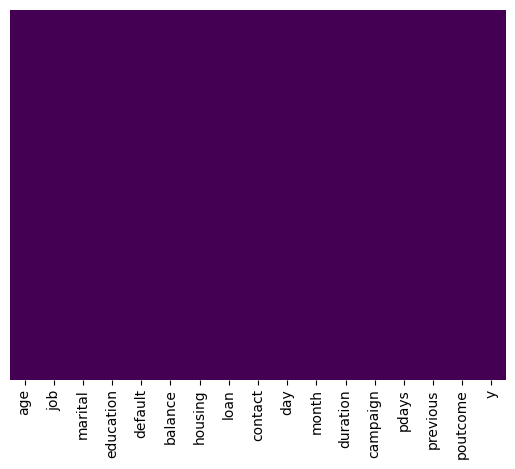

In [5]:
# Plot heatmap to visualize locations of missing values
sns.heatmap(orig_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [6]:
orig_df.shape

(4521, 17)

In [7]:
orig_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
orig_df['y'] = orig_df['y'].map({'yes': 1, 'no': 0})
orig_df['y'].value_counts()

y
0    4000
1     521
Name: count, dtype: int64

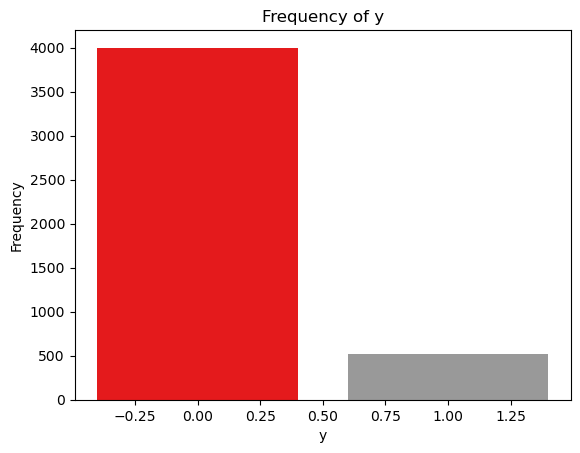

In [9]:
# Bar graph example
selected_var = 'y'
y = orig_df[selected_var].value_counts()
x_arr = y.index.tolist()

cmap = plt.cm.Set1
colors = cmap(np.linspace(0, 1, len(x_arr)))

fig, ax = plt.subplots()
ax.bar(x_arr, y, color=colors)

ax.set_xlabel(selected_var)
ax.set_ylabel('Frequency')
ax.set_title('Frequency of ' + selected_var)

#plt.tight_layout()
#plt.savefig('season_freq_bar.jpg')

plt.show()
# See more about bar graph at https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html

In [10]:
orig_y = orig_df['y']
orig_y

0       0
1       0
2       0
3       0
4       0
       ..
4516    0
4517    0
4518    0
4519    0
4520    0
Name: y, Length: 4521, dtype: int64

In [11]:
df = orig_df.copy()

In [12]:
orig_X = df.drop(['y'], axis=1)
orig_X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

In [13]:
# Finding categorical variables
cat_features = orig_X.select_dtypes(include=["object", "category"]).columns
cat_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [14]:
# Finding numerical variables
num_features = orig_X.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [15]:
num_orig_X = df[num_features]
num_orig_X.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

### Scaling

In [16]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_robust(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

### Encoding Categorical Data

In [17]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

In [18]:
# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

In [19]:
# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

In [20]:
# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

In [21]:
# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

In [22]:
# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

In [23]:
# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

In [24]:
### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Handling Imbalance

In [25]:
# Undersampling
def undersampling(X,y):
    from imblearn.under_sampling import RandomUnderSampler
    X_res, y_res = RandomUnderSampler().fit_resample(X, y)
    return X_res, y_res

In [26]:
# Oversampling
def oversampling(X,y):
    from imblearn.over_sampling import RandomOverSampler
    X_res, y_res = RandomOverSampler().fit_resample(X, y)
    return X_res, y_res

In [27]:
# SMOTE
def smote(X,y):
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE().fit_resample(X, y)
    return X_res, y_res

In [28]:
### See class weight example in Experiment problems

### Performance Evaluation

In [29]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [30]:
def plot_roc_auc(y_true, y_pred):
    from sklearn.metrics import roc_curve, roc_auc_score
    import matplotlib.pyplot as plt

    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (AUC = {auc:.3f})")
    plt.show()

    return auc

### Experiments

#### Baseline model

In [31]:
X = num_orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for i in [X_train, X_test, y_train, y_test]:
    print(i.shape)

(3616, 7)
(905, 7)
(3616,)
(905,)


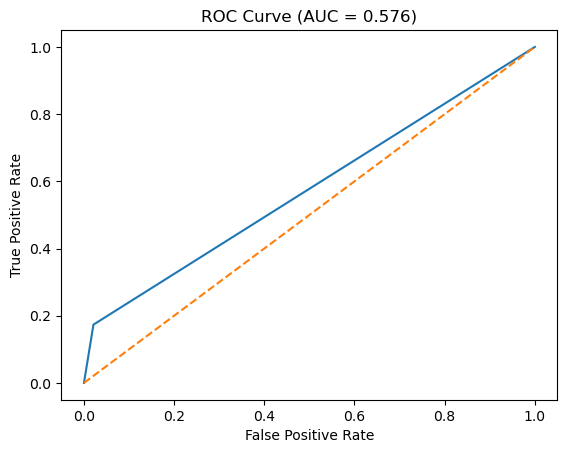

0.5762018562071669
[[790  17]
 [ 81  17]]
0.8917127071823204 0.7035017221584385 0.5762018562071669 0.599586448513743


In [32]:
# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.50      0.17      0.26        98

    accuracy                           0.89       905
   macro avg       0.70      0.58      0.60       905
weighted avg       0.86      0.89      0.87       905



### Encoding Categorical Data 

In [34]:
### >>> Let's use all features (both numerical and categoical features) to build the model
orig_X.shape

(4521, 16)

In [35]:
X = orig_X.copy()  
y = orig_y.copy()

X = onehot_encoder_all(X)
X.head()

,age_19,age_20,age_21,age_22,age_23,age_24,age_25,age_26,age_27,age_28,...,previous_19,previous_20,previous_22,previous_23,previous_24,previous_25,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


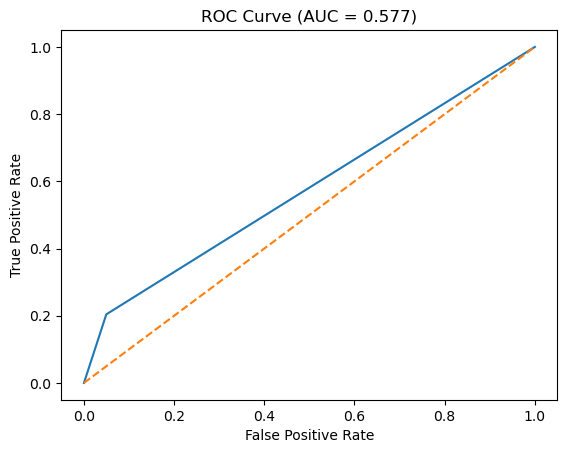

0.5772576688668033
[[767  40]
 [ 78  20]]
0.8696132596685083 0.6205128205128205 0.5772576688668032 0.590867992766727


In [36]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

In [37]:
### Question: How many columns of features before and after one-hot encoding?
### Answer: before -> 16, after -> 3718
X.shape

(4521, 3718)

In [38]:
### >>> Instruction: Let's add only 'marital', 'education' to help with model learning

In [39]:
num_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [40]:
encoded_vars = ['marital', 'education']
X = orig_X[num_features+encoded_vars].copy()
X.shape

(4521, 9)

In [41]:
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
X_train = onehot_encoder_selected(X_train, encoded_vars)
X_test = onehot_encoder_selected(X_test, encoded_vars)
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown
978,34,262,20,371,1,-1,0,True,False,False,False,False,True,False
251,32,2349,14,134,5,-1,0,False,True,False,False,False,True,False
3139,34,1076,8,70,2,-1,0,False,False,True,False,True,False,False
1822,31,156,13,657,7,-1,0,False,True,False,False,False,True,False
4445,46,258,27,217,1,-1,0,False,True,False,True,False,False,False


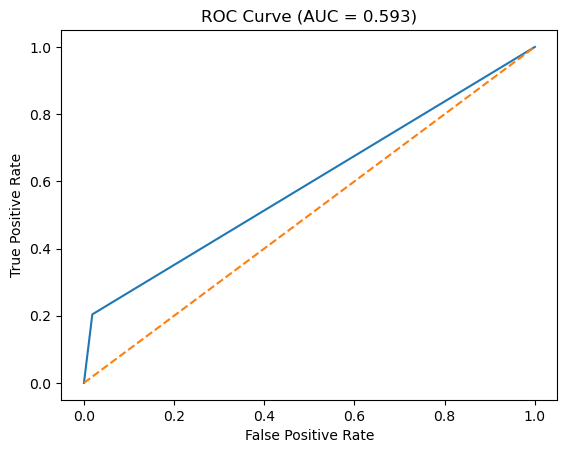

0.5927471360291329
[[792  15]
 [ 78  20]]
0.8972375690607735 0.7408866995073892 0.5927471360291329 0.6226478539820033


In [42]:
# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

In [43]:
### Question: How many columns of features before and after one-hot encoding only 'marital', 'education'?
### Answer: before -> 9, after -> 14
X_train.shape

(3616, 14)

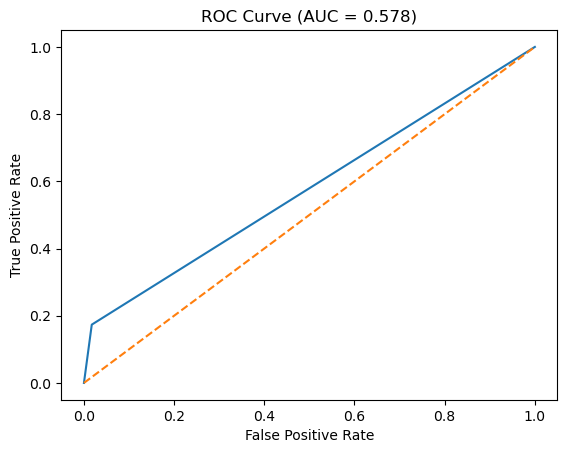

0.5780605922666464
[[793  14]
 [ 81  17]]
0.8950276243093923 0.727854875618218 0.5780605922666464 0.6035259558494621


In [44]:
encoded_vars = ['education']
X = orig_X[num_features+encoded_vars].copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Categorical Data Encoding ##############
## Label Encoder
encoded_var = 'education'
X_train = label_encoder(X_train, encoded_var)
X_test = label_encoder(X_test, encoded_var)
X_train.head()
#######################################################

# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

In [45]:
def new_X(encoded_vars):
    X = orig_X[num_features+encoded_vars].copy()
    y = orig_y.copy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test

In [46]:
### Ordinal Encoder Example
encoded_var = 'education'
X_train, X_test = new_X([encoded_var])
encode_order = ['unknown', 'primary', 'secondary', 'tertiary']  # Item1 = 0, Item2= 1, ... 
X_train = ordinal_encoder(X_train, encoded_var, encode_order)
X_test = ordinal_encoder(X_test, encoded_var, encode_order)
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,education
978,34,262,20,371,1,-1,0,3.0
251,32,2349,14,134,5,-1,0,3.0
3139,34,1076,8,70,2,-1,0,2.0
1822,31,156,13,657,7,-1,0,3.0
4445,46,258,27,217,1,-1,0,1.0


In [47]:
### Frequenct Encoder Example
encoded_var = 'education'
X_train, X_test = new_X([encoded_var])
X_train = frequent_encoder(X_train, encoded_var)
X_test = frequent_encoder(X_test, encoded_var)
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,education
978,34,262,20,371,1,-1,0,1073
251,32,2349,14,134,5,-1,0,1073
3139,34,1076,8,70,2,-1,0,1850
1822,31,156,13,657,7,-1,0,1073
4445,46,258,27,217,1,-1,0,543


In [48]:
### Target Encoder Example
encoded_var = 'education'
encoded_num = 'balance'
X_train, X_test = new_X([encoded_var])
X_train = target_encoder(X_train, encoded_var, encoded_num)
X_test = target_encoder(X_test, encoded_var, encoded_num)
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,education
978,34,262,20,371,1,-1,0,1800.082945
251,32,2349,14,134,5,-1,0,1800.082945
3139,34,1076,8,70,2,-1,0,1218.256757
1822,31,156,13,657,7,-1,0,1800.082945
4445,46,258,27,217,1,-1,0,1263.786372


In [49]:
### Binary Encoder Example
encoded_var = 'education'
X_train, X_test = new_X([encoded_var])
X_train = binary_encoder(X_train, encoded_var)
X_test = binary_encoder(X_test, encoded_var)
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,education_bin_0,education_bin_1,education_bin_2
978,34,262,20,371,1,-1,0,0,0,1
251,32,2349,14,134,5,-1,0,0,0,1
3139,34,1076,8,70,2,-1,0,0,1,0
1822,31,156,13,657,7,-1,0,0,0,1
4445,46,258,27,217,1,-1,0,0,1,1


In [50]:
### Hash Encoding Example
encoded_var = 'education'
X_train, X_test = new_X([encoded_var])
hash_len = 4  # #bits to represent size of education
X_train = hash_encoder(X_train, encoded_var, hash_len)
X_test = hash_encoder(X_test, encoded_var, hash_len)
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,education_hash_0,education_hash_1,education_hash_2,education_hash_3
978,34,262,20,371,1,-1,0,0,0,1,0
251,32,2349,14,134,5,-1,0,0,0,1,0
3139,34,1076,8,70,2,-1,0,1,0,0,0
1822,31,156,13,657,7,-1,0,0,0,1,0
4445,46,258,27,217,1,-1,0,0,0,1,0


Confusion table
TP   FP
FN   TN

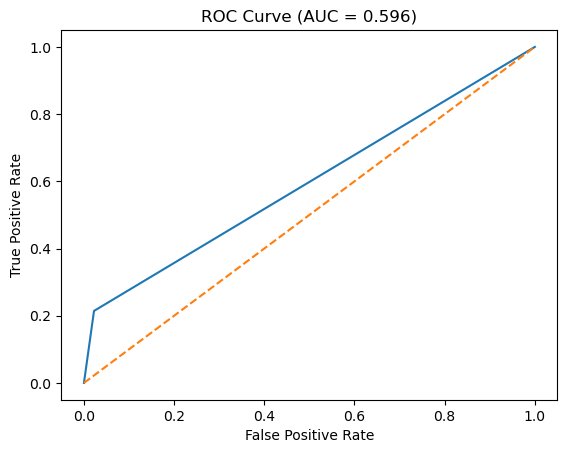

Confusion: [[789  18]
 [ 77  21]]
AUC: 0.59599, acc: 0.89503, precision: 0.72477, recall: 0.59599, f1: 0.62489


In [51]:
encoded_vars = ['education']
X = orig_X[num_features+encoded_vars].copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Replace Categorical Data Encoding here ##############
encoded_var = 'education'
# label
# X_train = label_encoder(X_train, encoded_var)
# X_test = label_encoder(X_test, encoded_var)
# ordinal
# encoded_order = ['unknown', 'primary', 'secondary', 'tertiary']
# X_train = ordinal_encoder(X_train, encoded_var, encoded_order)
# X_test = ordinal_encoder(X_test, encoded_var, encoded_order)
# frequent
# X_train = frequent_encoder(X_train, encoded_var)
# X_test = frequent_encoder(X_test, encoded_var)
# target
# encoded_num = 'balance'
# X_train = target_encoder(X_train, encoded_var, encoded_num)
# X_test = target_encoder(X_test, encoded_var, encoded_num)
# binary
X_train = binary_encoder(X_train, encoded_var)
X_test = binary_encoder(X_test, encoded_var)
# hash
# hash_len = 4
# X_train = hash_encoder(X_train, encoded_var, hash_len)
# X_test = hash_encoder(X_test, encoded_var, hash_len)

X_train.head()
####################################################################

# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
# print(f"AUC: {auc:.5f}")

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(f"Confusion: {confusion}")
# print(f"acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")
print(f"AUC: {auc:.5f}, acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")

In [52]:
### Question: Not including one-hot encoding, which categorical data encoding gives the best performance?
### Instruction: Show your work and give the answer below
### Annswer: binary encoding
#
# label -> AUC: 0.57806, acc: 0.89503, precision: 0.72785, recall: 0.57806, f1: 0.60353
#
# ordinal -> AUC: 0.57806, acc: 0.89503, precision: 0.72785, recall: 0.57806, f1: 0.60353
# 
# frequent -> AUC: 0.58130, acc: 0.89282, precision: 0.71117, recall: 0.58130, f1: 0.60642
#
# target -> AUC: 0.57620, acc: 0.89171, precision: 0.70350, recall: 0.57620, f1: 0.59959
#
# binary -> AUC: 0.59599, acc: 0.89503, precision: 0.72477, recall: 0.59599, f1: 0.62489
#
# hash -> AUC: 0.57682, acc: 0.89282, precision: 0.71113, recall: 0.57682, f1: 0.60088

In [53]:
cat_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [54]:
df['job'].unique()

array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

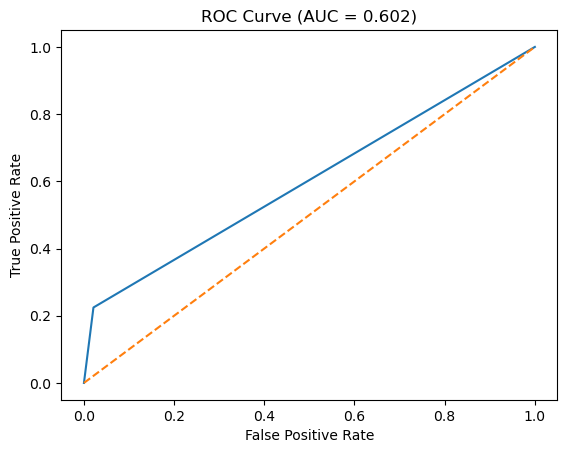

Confusion: [[790  17]
 [ 76  22]]
AUC: 0.60171, acc: 0.89724, precision: 0.73817, recall: 0.60171, f1: 0.63279


In [55]:
encoded_vars = ['job']
X = orig_X[num_features+encoded_vars].copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Replace Categorical Data Encoding here ##############
encoded_var = 'job'
# label
# X_train = label_encoder(X_train, encoded_var)
# X_test = label_encoder(X_test, encoded_var)
# ordinal
# encoded_order = ['unemployed', 'services', 'management', 'blue-collar',
#       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
#       'housemaid', 'retired', 'unknown']
# X_train = ordinal_encoder(X_train, encoded_var, encoded_order)
# X_test = ordinal_encoder(X_test, encoded_var, encoded_order)
# frequent
# X_train = frequent_encoder(X_train, encoded_var)
# X_test = frequent_encoder(X_test, encoded_var)
# target
encoded_num = 'balance'
X_train = target_encoder(X_train, encoded_var, encoded_num)
X_test = target_encoder(X_test, encoded_var, encoded_num)
# binary
# X_train = binary_encoder(X_train, encoded_var)
# X_test = binary_encoder(X_test, encoded_var)
# hash
# hash_len = 4
# X_train = hash_encoder(X_train, encoded_var, hash_len)
# X_test = hash_encoder(X_test, encoded_var, hash_len)

X_train.head()
####################################################################

# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
# print(f"AUC: {auc:.5f}")

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(f"Confusion: {confusion}")
# print(f"acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")
print(f"AUC: {auc:.5f}, acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")

In [56]:
### Question: Try (1) another categorical data and 
###               (2) some encoding methods 
###           that results to the better performance than numerical features + education feature.
### Instruction: Show your work and give the answer below
### Answer: encoded 'job' with target encoder using 'balance' as a encoder num
###         AUC: 0.60171, acc: 0.89724, precision: 0.73817, recall: 0.60171, f1: 0.63279

### Imbalance Handling

(846, 7) (846,)


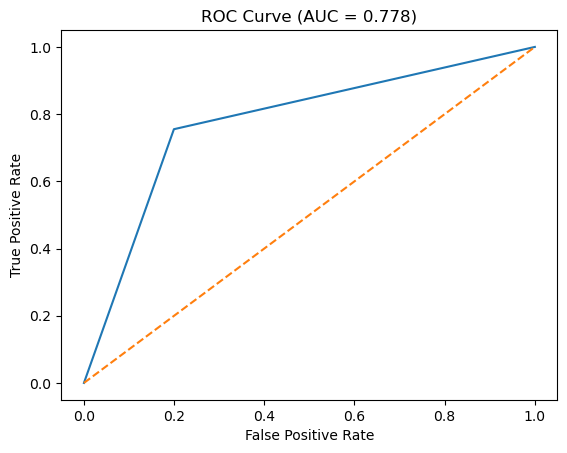

Confusion: [[646 161]
 [ 24  74]]
AUC: 0.77780, acc: 0.79558, precision: 0.63954, recall: 0.77780, f1: 0.65960


In [57]:
# Undersampling
X = num_orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Replace Imbalance Handling here ##############
X_train, y_train = undersampling(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()
#############################################################

# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
# print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
# print(confusion)
# print(acc, precision, recall, f1)
print(f"Confusion: {confusion}")
# print(f"acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")
print(f"AUC: {auc:.5f}, acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")

(6386, 7) (6386,)


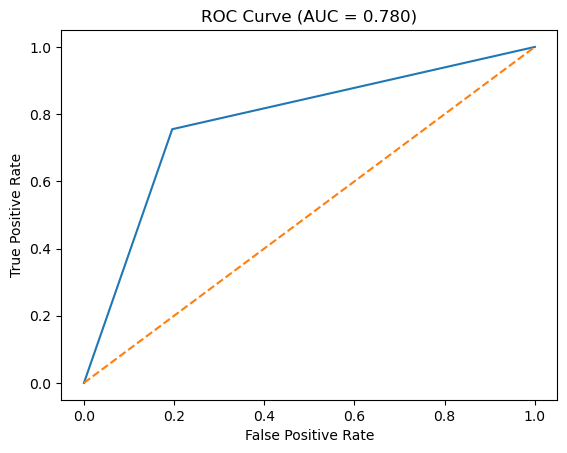

Confusion: [[649 158]
 [ 24  74]]
AUC: 0.77966, acc: 0.79890, precision: 0.64165, recall: 0.77966, f1: 0.66276


In [58]:
# Oversampling
X = num_orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Replace Imbalance Handling here ##############
X_train, y_train = oversampling(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()
#############################################################

# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
# print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
# print(confusion)
# print(acc, precision, recall, f1)
print(f"Confusion: {confusion}")
# print(f"acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")
print(f"AUC: {auc:.5f}, acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")

(6386, 7) (6386,)


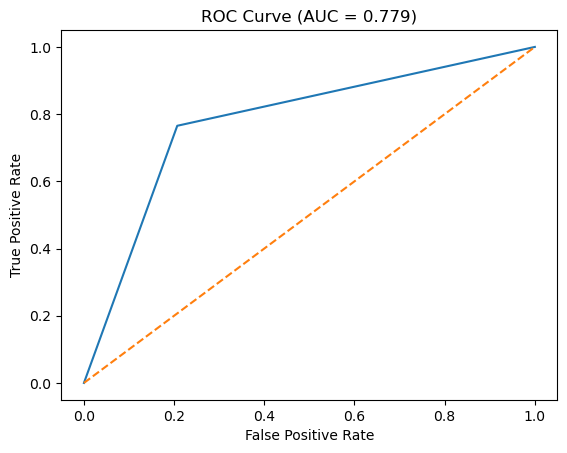

Confusion: [[640 167]
 [ 23  75]]
AUC: 0.77918, acc: 0.79006, precision: 0.63761, recall: 0.77918, f1: 0.65596


In [59]:
# SMOTE
X = num_orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Replace Imbalance Handling here ##############
X_train, y_train = smote(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()
#############################################################

# Scaling
X_train, X_test = scale_standard(X_train, X_test)

# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
# print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
# print(confusion)
# print(acc, precision, recall, f1)
print(f"Confusion: {confusion}")
# print(f"acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")
print(f"AUC: {auc:.5f}, acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")

In [60]:
# Oversampling Example
X_train, y_train = oversampling(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()

# Smote Example
X_train, y_train = smote(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()

(6386, 7) (6386,)
(6386, 7) (6386,)


y
0    3193
1    3193
Name: count, dtype: int64

{0: 1.0, 1: 20.0}


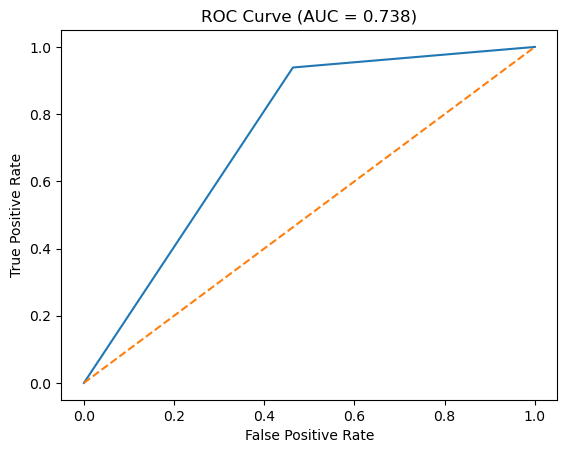

Confusion: [[433 374]
 [  6  92]]
AUC: 0.73767, acc: 0.58011, precision: 0.59188, recall: 0.73767, f1: 0.51063


In [61]:
### Class Weight Example
X = num_orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weight_dict = {0: 1.0,   # majority
                     1: 20.0   # minority
                   }
print(class_weight_dict)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight=class_weight_dict, max_iter=1000)
model.fit(X_train, y_train)

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
# print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
# print(confusion)
# print(acc, precision, recall, f1)
print(f"Confusion: {confusion}")
# print(f"acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")
print(f"AUC: {auc:.5f}, acc: {acc:.5f}, precision: {precision:.5f}, recall: {recall:.5f}, f1: {f1:.5f}")

In [62]:
### Question: From the previous model (the one that gives better performance than numerical features + education feature)
###           Apply the imbalance handling and find out which imbalance handling methods gives the best performance
### Instruction: Show your work and give the answer below
### Annswer: Oversampling gives the best performance
###          with AUC: 0.77332, acc: 0.79558, precision: 0.63805, recall: 0.77332, f1: 0.65800